In [1]:
#Intrusion detedction using ML on the NSL-KDD dataset
#Author: Elham Taridashti /// Email:tari.elham70@gmail.com
#Models: LogisticRegression, Decision tree and SVM
#Goal: Develop and compare ML models for network intrusion detection using the NSL-KDD dataset.
#--------------------------

In [51]:
#import Required Libraries
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier 
from sklearn.svm import SVC

from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
confusion_matrix,
classification_report
)

In [52]:
#load the NSL-KDD Dataset

train = pd.read_csv("KDDTrain+.txt", header=None)
test = pd.read_csv("KDDTest+.txt", header=None)

In [53]:
#Exploratory Data Analysis(EDA)

print(train.head())
print(train.shape)
print(train.info)
print(test.shape)

   0    1         2   3    4     5   6   7   8   9   ...    33    34    35  \
0   0  tcp  ftp_data  SF  491     0   0   0   0   0  ...  0.17  0.03  0.17   
1   0  udp     other  SF  146     0   0   0   0   0  ...  0.00  0.60  0.88   
2   0  tcp   private  S0    0     0   0   0   0   0  ...  0.10  0.05  0.00   
3   0  tcp      http  SF  232  8153   0   0   0   0  ...  1.00  0.00  0.03   
4   0  tcp      http  SF  199   420   0   0   0   0  ...  1.00  0.00  0.00   

     36    37    38    39    40       41  42  
0  0.00  0.00  0.00  0.05  0.00   normal  20  
1  0.00  0.00  0.00  0.00  0.00   normal  15  
2  0.00  1.00  1.00  0.00  0.00  neptune  19  
3  0.04  0.03  0.01  0.00  0.01   normal  21  
4  0.00  0.00  0.00  0.00  0.00   normal  21  

[5 rows x 43 columns]
(125973, 43)
<bound method DataFrame.info of         0    1         2   3     4     5   6   7   8   9   ...    33    34  \
0        0  tcp  ftp_data  SF   491     0   0   0   0   0  ...  0.17  0.03   
1        0  udp     other

In [4]:
#Data Preprocessing 

columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes',
    'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
    'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
    'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
    'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate',
    'dst_host_srv_serror_rate',
    'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate',
    'label',
    'difficulty'
]

train.columns = columns
test.columns = columns




In [5]:
#Missing Values in Train?

train.isnull().sum()

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

In [6]:
#How many unique data points are there?
print(train['protocol_type'].unique())
print(train['protocol_type'].nunique())

['tcp' 'udp' 'icmp']
3


In [7]:
#How many unique data points are there?

print(train['flag'].unique())
print(train['flag'].nunique())

['SF' 'S0' 'REJ' 'RSTR' 'SH' 'RSTO' 'S1' 'RSTOS0' 'S3' 'S2' 'OTH']
11


In [8]:
#How many unique data points are there?
print(train['service'].unique())
print(train['service'].nunique())

['ftp_data' 'other' 'private' 'http' 'remote_job' 'name' 'netbios_ns'
 'eco_i' 'mtp' 'telnet' 'finger' 'domain_u' 'supdup' 'uucp_path' 'Z39_50'
 'smtp' 'csnet_ns' 'uucp' 'netbios_dgm' 'urp_i' 'auth' 'domain' 'ftp'
 'bgp' 'ldap' 'ecr_i' 'gopher' 'vmnet' 'systat' 'http_443' 'efs' 'whois'
 'imap4' 'iso_tsap' 'echo' 'klogin' 'link' 'sunrpc' 'login' 'kshell'
 'sql_net' 'time' 'hostnames' 'exec' 'ntp_u' 'discard' 'nntp' 'courier'
 'ctf' 'ssh' 'daytime' 'shell' 'netstat' 'pop_3' 'nnsp' 'IRC' 'pop_2'
 'printer' 'tim_i' 'pm_dump' 'red_i' 'netbios_ssn' 'rje' 'X11' 'urh_i'
 'http_8001' 'aol' 'http_2784' 'tftp_u' 'harvest']
70


In [9]:
#One-Hot encoding of categorical features 

train= pd.get_dummies(
    train,
    columns=['protocol_type', 'service' ,'flag']
)
test= pd.get_dummies(
    test,
    columns=['protocol_type', 'service','flag']
)

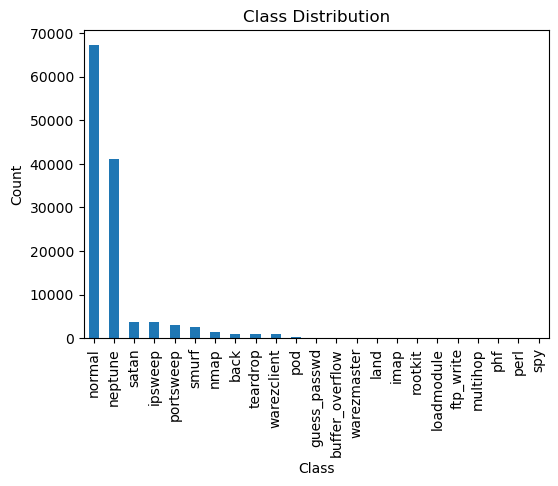

In [10]:
#Is the Data Balanced?

plt.figure(figsize=(6,4))

train["label"].value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [11]:
#Data Analysis
print(train.shape)
print(test.shape)

(125973, 124)
(22544, 118)


In [12]:
train["label"].value_counts().head(20)

label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
Name: count, dtype: int64

In [13]:
#label(target) encoding--> Binary Classification

train["label"]= train["label"].apply(
     lambda x: 0 if x == "normal" else 1
)

test["label"]= test["label"].apply(
     lambda x: 0 if x == "normal" else 1
)

#check target distribution

print(train["label"].value_counts())
print(test["label"].value_counts())

label
0    67343
1    58630
Name: count, dtype: int64
label
1    12833
0     9711
Name: count, dtype: int64


In [14]:
#make train & test have exactly the same columns

train, test=train.align(test, join="left", axis=1, fill_value=0)

print(train.shape)
print(test.shape)

(125973, 124)
(22544, 124)


In [15]:
#Remove the difficulty column
train=train.drop(columns=["difficulty"])
test=test.drop(columns=["difficulty"])

In [16]:
#Features and Target Separation

x_train= train.drop(columns=["label"])
x_test= test.drop(columns=["label"])

y_train= train["label"]
y_test=test["label"]

print(train.shape)
print(test.shape)

(125973, 123)
(22544, 123)


In [17]:
#Feature Scaling
scaler=StandardScaler()

x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)


In [18]:
#getting info after scaling
print(x_train.shape)
print(x_test.shape)

(125973, 122)
(22544, 122)


In [19]:
#Create LogisticResfression Model & Training

import time

lr_model=LogisticRegression(random_state=42)

#Measure Training Time

start = time.time()
lr_model.fit(x_train, y_train)
end = time.time()
lr_time = end - start
print(f"Training Time: {lr_time:.4f} seconds")


Training Time: 3.6929 seconds


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [20]:
# Prediction stage

y_pred_lr=lr_model.predict(x_test)

In [21]:
#Logistic Regression Evaluation

accuracy=accuracy_score(y_test,y_pred_lr)
precision=precision_score(y_test, y_pred_lr)
recall=recall_score(y_test,y_pred_lr)
f1=f1_score(y_test, y_pred_lr)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Accuracy: 0.7532824698367636
Precision: 0.917154331612163
Recall: 0.6228473466843295
F1 Score: 0.7418785966214962


In [22]:
#Required Report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.65      0.93      0.76      9711
           1       0.92      0.62      0.74     12833

    accuracy                           0.75     22544
   macro avg       0.78      0.77      0.75     22544
weighted avg       0.80      0.75      0.75     22544



In [23]:
#Confusion Matrix

confusion_matrix(y_test, y_pred_lr)


array([[8989,  722],
       [4840, 7993]])

In [24]:
#Display of Confusion Matrix

cm=confusion_matrix(y_test, y_pred_lr)
print(cm)

[[8989  722]
 [4840 7993]]


In [25]:
#Create of Decision Tree & Training

dt_model=DecisionTreeClassifier(random_state=42)

#Measuring Training time 
start= time.time()
dt_model.fit(x_train, y_train)
end= time.time()
dt_time= end - start
print(f"Training Time: {dt_time:.4f} seconds")


Training Time: 2.1965 seconds


In [26]:
#Prediction stage

y_pred_dt=dt_model.predict(x_test)

In [27]:
#Decision Tree Evaluation

accuracy_dt=accuracy_score(y_test,y_pred_dt)
precision_dt=precision_score(y_test, y_pred_dt)
recall_dt=recall_score(y_test,y_pred_dt)
f1_dt=f1_score(y_test, y_pred_dt)

print("Accuracy:", accuracy_dt)
print("Precision:", precision_dt)
print("Recall:", recall_dt)
print("F1 Score:", f1_dt)


Accuracy: 0.7854418026969482
Precision: 0.9647756335735875
Recall: 0.6466921218732954
F1 Score: 0.7743410310240261


In [28]:
#Required Report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.67      0.97      0.80      9711
           1       0.96      0.65      0.77     12833

    accuracy                           0.79     22544
   macro avg       0.82      0.81      0.78     22544
weighted avg       0.84      0.79      0.78     22544



In [29]:
#Confusion Matrix

print(confusion_matrix(y_test, y_pred_dt))

[[9408  303]
 [4534 8299]]


In [30]:
#Create of Support Vector Machine(SVM) & training

svm_model=SVC(random_state=42)

#Measuring Traing Time
start = time.time()
svm_model.fit(x_train, y_train)
end = time.time()
svm_time = end - start
print(f"Training Time: {svm_time:.4f} seconds")


Training Time: 211.9250 seconds


In [31]:
#prediction stage

y_pred_svm=svm_model.predict(x_test)

In [32]:
#SVM Evaluation

accuracy_svm=accuracy_score(y_test,y_pred_svm)
precision_svm=precision_score(y_test, y_pred_svm)
recall_svm=recall_score(y_test,y_pred_svm)
f1_svm=f1_score(y_test, y_pred_svm)

print("Accuracy:", accuracy_svm)
print("Precision:", precision_svm)
print("Recall:", recall_svm)
print("F1 Score:", f1_svm)

Accuracy: 0.7869499645138396
Precision: 0.9254079254079254
Recall: 0.6805891062105509
F1 Score: 0.7843383772619101


In [33]:
#Required Report

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.69      0.93      0.79      9711
           1       0.93      0.68      0.78     12833

    accuracy                           0.79     22544
   macro avg       0.81      0.80      0.79     22544
weighted avg       0.82      0.79      0.79     22544



In [34]:
#Confusion Matrix

print(confusion_matrix(y_test, y_pred_svm))

[[9007  704]
 [4099 8734]]


In [35]:
#Comparison of Models

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "SVM"
    ],
    "Accuracy": [
        accuracy,
        accuracy_dt,
        accuracy_svm
    ],
    "Precision": [
        precision,
        precision_dt,
        precision_svm
    ],
    "Recall": [
        recall,
        recall_dt,
        recall_svm
    ],
    "F1-score": [
        f1,
        f1_dt,
        f1_svm
    ]
})


#Sort of Report Based on Accuracy

results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-score
2,SVM,0.786950,0.925408,0.680589,0.784338
1,Decision Tree,0.785442,0.964776,0.646692,0.774341
0,Logistic Regression,0.753282,0.917154,0.622847,0.741879


In [36]:
#Create of Heatmap

import seaborn as sns

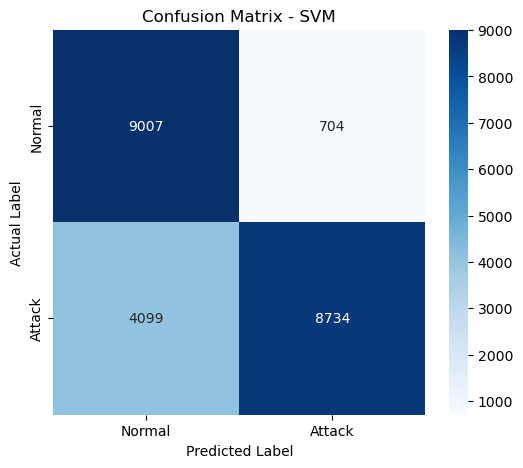

In [37]:
# Confusion Matrix for SVM

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"]
)

plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

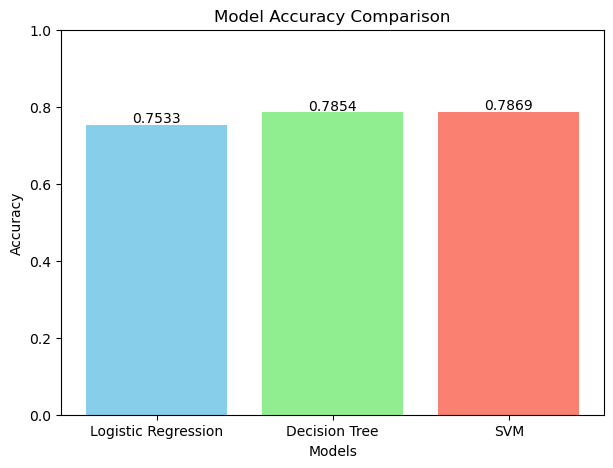

In [50]:
#Create of line Charts from Accuracy

plt.figure(figsize=(7,5))

plt.bar(results["Model"], results["Accuracy"], color=["skyblue", "lightgreen", "salmon"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

for i, v in enumerate(results["Accuracy"]):
    plt.text(i, v + 0.005, f"{v:.4f}", ha="center")

plt.show()

In [49]:
#The Table Bellow Summarizes the Results of the Three Models!

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "SVM"
    ],
    "Accuracy": [
        accuracy,
        accuracy_dt,
        accuracy_svm        
    ],
    "Precision":[
        precision,
        precision_dt,
        precision_svm
    ],
    "Recall":[
        recall,
        recall_dt,
        recall_svm
    ],
    "F1-score":[
        f1,
        f1_dt,
        f1_svm
    ],
    "Training Time (s)": [
        lr_time,
        dt_time,
        svm_time
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1-score  \
0  Logistic Regression  0.753282   0.917154  0.622847  0.741879   
1        Decision Tree  0.785442   0.964776  0.646692  0.774341   
2                  SVM  0.786950   0.925408  0.680589  0.784338   

   Training Time (s)  
0           3.692852  
1           2.196536  
2         211.924959  


In [48]:
#Conclusion

#Three machine learning models (LogisticRegression, Decission Tree, SVM)  were evaluated on the NSL-KDD intrusion detection dataset!

#Among the evaluated models, Support Vector Machine (SVM) achieved the highest classification accuracy and F1-score, demonstrating its effectiveness for binary intrusion detection.

#Decision Tree provided competitive performance with faster training, while Logistic Regression served as a simple baseline model.

#Future work may include ensemble learning methods, hyperparameter optimization, and deep learning approaches.

#Elham Taridashti, Email: tari.elham70@gmail.com